In [1]:
%matplotlib inline

import math
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import amjuel
import ehr
import xsection as xs

We use the H collisional radiative code *collrad* to model the fate of the products of H$_{2}^{+}$ dissociation:

$\frac{N_{n}}{n_{H_{2}^{+}}} = - (Q^{-1})_{nm} E_{H_{2}^+,m} - (Q^{-1})_{nm} \alpha_{m} \equiv R_{H}^{H_{2}^{+}}(p) + R_{2H}^{H_{2}^{+}}(p)$,

The first of the two terms on the right hand side represents the products of dissociative excitation.  The Janev, Langer, Evans and Post (JLEP) dissociative excitation process (2.2.13) provided only the production rate of $n=2$ atoms.  Reiter's 1992 PSI paper proposed an *ad hoc* procedure for estimating the $n=3$ production rate, which was used in DEGAS and then in the initial implementation of this process in DEGAS 2.  Reiter now instead uses Sawada's code which has a hardwired $1/n^{3}$ scaling for the higher states so that:

$E_{H_{2}^+,m} = [1, (2/3)^3, (2/4)^{3}, ... (2/m)^{3} ... ] < \sigma v>_{(2.2.13)}$.

The second term on the right hand side corresponds to dissociative recombination, (2.2.14).  In this case, JLEP does provide a scaling:

$\alpha_{m} = [0.1, 0.45, 0.22, 0.12, 0.069, ... (10/m^{3}) ... ] < \sigma v>_{(2.2.14)}$.

Using the notation from Kotov's thesis, we can then write out the expression for the **effective dissociation recombination rate for H$_{2}^{+}$**:

**Dissociative Recombination:**

$R_{H_{2}^{+}} = \sum_{p^{\prime} > 1} [ A_{H}(p^{\prime},1)/n_{e} + F_{H}(p^{\prime},1) ] R_{2H}^{H_{2}^{+}}(p^{\prime}) = \sum_{p^{\prime} > 1} [ \alpha(p^{\prime}) - S_{H}(p^{\prime}) R_{2H}^{H_{2}^{+}}(p^{\prime})]$.

All of the terms have already been defined, with $\alpha(p^{\prime})$ being the same function as $\alpha_{m}$ in the expression at the top of the page.   The first expression immediately above represents decay of the excited states to the ground state; the second, equivalent expression represents the total source minus the rate of ionization of the excited states.  The collisional radiative code *collrad* uses the first of these two.

We get the resulting $R_{H_{2}^{+}}$ from the fort.19 file written out by *collrad*:

In [2]:
h2cr_19_saw = ehr.ehr_data('fort.19')
print(h2cr_19_saw.data_dict.keys())

dict_keys(['  H2 Dissociation Rate(jt,jn) (cm**3 s**-1)  Te(jt) = 10**(-1.2 + (jt-1)/10) jt=1,60\n', '  H2 Dissociative Ionization Rate(jt,jn) (cm**3 s**-1)\n', '  H2+ Dissociative Recombination Rate(jt,jn)  (cm**3 s**-1)\n', '  H2+ Dissociation Rate(jt,jn)  (cm**3 s**-1)\n', '  H2+ Dissociative Ionization Rate(jt,jn)  (cm**3 s**-1)\n', '  H2 Dissociative Excitation n=3 / n=1 (jt,jn)\n', '  H2+ Dissociative Excitation n=3 / n=1 (jt,jn)\n', '  H2+ Dissociative Recombination n=3 / n=1 (jt,jn)\n', '  H2 Dissociative Excitation n=2 / n=1 (jt,jn)\n', '  H2+ Dissociative Excitation n=2 / n=1 (jt,jn)\n', '  H2+ Dissociative Recombination n=2 / n=1 (jt,jn)\n', ' H2 Dissociative Excitation n=4 / n=1 (jt,jn)\n', ' H2+ Dissociative Excitation n=4 / n=1 (jt,jn)\n', ' H2+ Dissociative Recombination n=4 / n=1 (jt,jn)\n', ' H2 Dissociative Excitation n=5 / n=1 (jt,jn)\n', ' H2+ Dissociative Excitation n=5 / n=1 (jt,jn)\n', ' H2+ Dissociative Recombination n=5 / n=1 (jt,jn)\n', ' H2 Dissociative Excit

In [3]:
R_H2p = h2cr_19_saw.get_one_var('H2+ Dissociative Recombination Rate')

We read in the corresponding rates from AMJUEL only for verification:

In [4]:
amj_file = 'amjuel.tex'

Use the same grid for the two sets of data.

In [5]:
ehr19Te = h2cr_19_saw.get_Te()
ehr19ne = h2cr_19_saw.get_ne()
num_Te = ehr19Te.shape[0]
num_ne = ehr19ne.shape[0]

In [6]:
H123 = 'H.4'
reacstr = '2.2.14'
fit_coef = amjuel.get_AMJUEL_fit(amj_file,H123,reacstr)
data_2214 = np.zeros((num_ne,num_Te))
for jt in range(num_Te):
    for jn in range(num_ne):
        data_2214[jn,jt] = amjuel.ne_Te_exp_fit(fit_coef,ehr19ne[jn],ehr19Te[jt])

/Users/dstotler/degas2/data/H2_CR_model/amjuel.py:64: RuntimeWarning: overflow encountered in exp
  fit = np.exp(fit)


We will be comparing with the reaction rate previously used by DEGAS 2 for this process, which is just rate associated with the fit for JLEP reaction (2.2.14).  

In [7]:
data_dir = '../'
h2pdisrec_nc = xs.xs_netCDF.read_ncfile('h2pdisrec',data_dir)
h2pdisrec_nc.xs.list_vars()
print('  ')
h2pdisrec_nc.xs.print_var(0)
old_rate = h2pdisrec_nc.xs.get_var4plot(0)
print('  ')
h2pdisrec_nc.xs.print_var(1)
old_eloss = h2pdisrec_nc.xs.get_var4plot(1)

 j              Name                   Units     
 0 reaction_rate                  cm^3/s         
 1 background_energy_loss_rate    eV*cm^3/s      
 2 dissociation_energy            eV             
 3 emission_rate                  eV*cm^3/s      
 4 wavelength_H_alpha             Angstroms      
 5 wavelength_D_alpha             Angstroms      
 6 wavelength_T_alpha             Angstroms      
  
Dependent variable:  reaction_rate  Units:  cm^3/s 
 Multiplier:  1.00000e-06  Spacing:  log 

  Indep. var.     Units    Multiplier  Spacing     Min.        Max.    
temperature     eV         1.60218e-19 log      1.00000e+00 5.01187e+04
  
Dependent variable:  background_energy_loss_rate  Units:  eV*cm^3/s 
 Multiplier:  1.60218e-25  Spacing:  log 

  Indep. var.     Units    Multiplier  Spacing     Min.        Max.    
temperature     eV         1.60218e-19 log      1.00000e+00 5.01187e+04


Make a comparison plot.  

The designation "JCR" here and in the name of this and the other associated molecular dissociation reaction files stands for "Janev Collisional Radiative" since the original approach was to use the Janev rates for the dissociative excitation product distribution in *collrad*.

The previous DEGAS 2 rate for this process, without collisional radiative effects, is included for comparison.  

The different colors represent different densities, as is indicated by the legend.

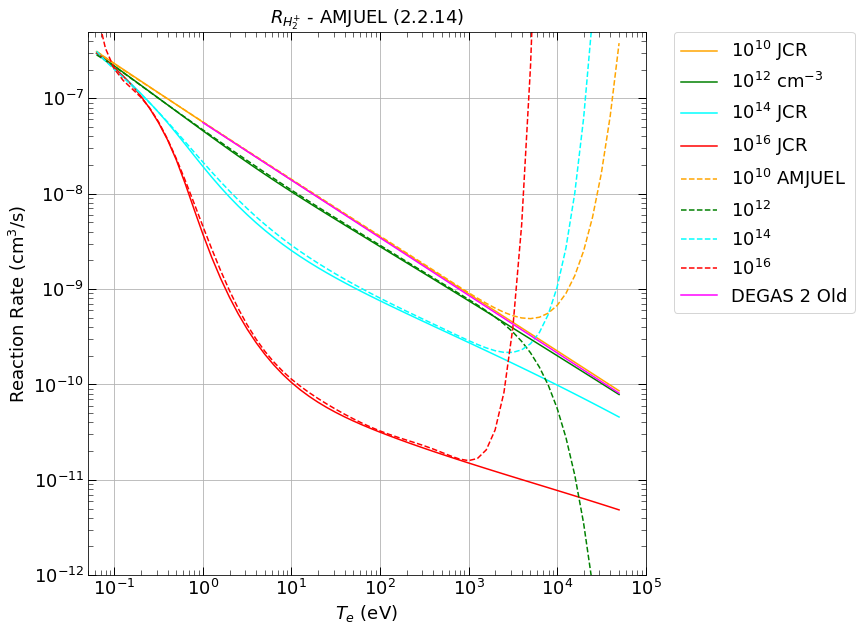

In [8]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,R_H2p[0,:],label='$10^{10}$ JCR',color='orange')
plt.plot(ehr19Te,R_H2p[4,:],label='$10^{12}$ cm$^{-3}$',color='green')
plt.plot(ehr19Te,R_H2p[8,:],label='$10^{14}$ JCR',color='cyan')
plt.plot(ehr19Te,R_H2p[12,:],label='$10^{16}$ JCR',color='red')
plt.plot(ehr19Te,data_2214[0,:],label='$10^{10}$ AMJUEL',ls='--',color='orange')
plt.plot(ehr19Te,data_2214[4,:],label='$10^{12}$',ls='--',color='green')
plt.plot(ehr19Te,data_2214[8,:],label='$10^{14}$',ls='--',color='cyan')
plt.plot(ehr19Te,data_2214[12,:],label='$10^{16}$',ls='--',color='red')
plt.plot(old_rate[0],old_rate[1],label='DEGAS 2 Old',color='magenta')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Reaction Rate (cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
plt.gca().set_xlim((0.05,1.e5))
plt.gca().set_ylim((1.e-12,5.e-7))
plt.gca().grid(axis='both',which='major')
plt.title('$R_{H_{2}^{+}}$ - AMJUEL (2.2.14)',fontsize=18)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',borderaxespad=0,fontsize=18)

The JCR rates closely follow those from AMJUEL, except at the extreme $T_{e}$ values where the AMJUEL fits break down.  Moreover, the coronal limit of these lines up well with the old DEGAS 2 rate, as expected.

The dissociation energy and electron energy loss rates *differ* from those in the Janev book. The former comes from a private communication by Janev stating that the dissociation energy should be $0.5(8.6 + 13.6/n^{2})$; with $n = 3$ (the dominant pathway), this is 5.1 eV, which is what was used previously in DEGAS 2 (see old_ediss below).  The electron energy loss per recombination event is given by $1.5 T_{e} / 1.7$; the 1.7 comes from averaging the electron energy over the cross section, as was described in D. Reiter, P. Bogen, and U. Samm, J. Nucl. Mater. **196–198**, 1059 (1992).  This is essentially the same rate as in AMJUEL H.8 (2.2.14).

In [9]:
E_diss = 5.1
E_loss_rate = np.zeros_like(R_H2p)
for jn in range(num_ne):
    E_loss_rate[jn,:] = (1.5*ehr19Te[:]/1.7)*R_H2p[jn,:]

In [10]:
h2pdisrec_nc.xs.print_var(2)
old_ediss = h2pdisrec_nc.xs.get_var4plot(2)
print(old_ediss)

Dependent variable:  dissociation_energy  Units:  eV 
 Multiplier:  1.60218e-19  Spacing:  linear 

  Indep. var.     Units    Multiplier  Spacing     Min.        Max.    
[5.1]


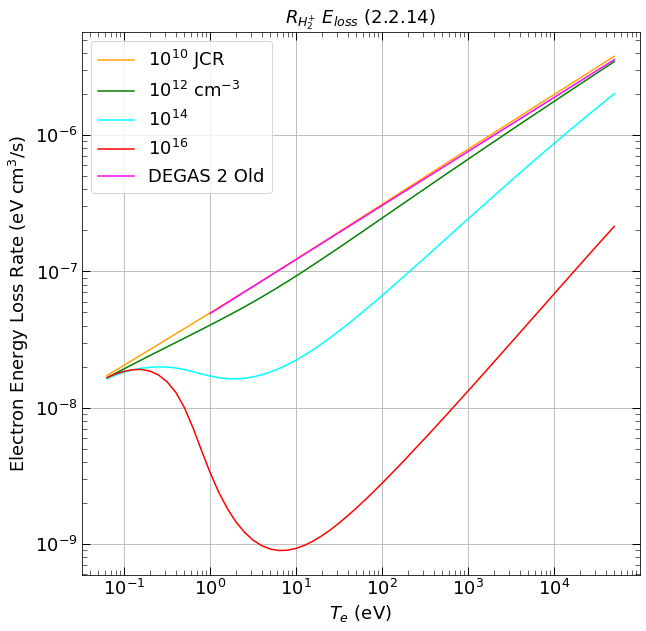

In [11]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,E_loss_rate[0,:],
         label='$10^{10}$ JCR',color='orange')
plt.plot(ehr19Te,E_loss_rate[4,:],
         label='$10^{12}$ cm$^{-3}$',color='green')
plt.plot(ehr19Te,E_loss_rate[8,:],
         label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,E_loss_rate[12,:],
         label='$10^{16}$',color='red')
plt.plot(old_eloss[0],old_eloss[1],label='DEGAS 2 Old',color='magenta')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Electron Energy Loss Rate (eV cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
#plt.gca().set_xlim((1.,1.e3))
#plt.gca().set_ylim((5.e-8,3.e-6))
plt.gca().grid(axis='both',which='major')
plt.title('$R_{H_{2}^{+}}$ $E_{loss}$ (2.2.14)',fontsize=18)
plt.legend(fontsize=18)

As is done for H CR data, e.g., in hionize5.nc, we provide the emission rate for photons, as a power, rather than the excited state population coefficients.  First, extract the data for all excited states from the file.  Since AMJUEL only provides a fit for the combination of the dissociative excitation and recombination, we read in the *collrad* data for both, then plot the sum and the recombination portion (an analogous plot in the h2pdis_jcr.ipynb notebook isolates the contribution from excitation). Note that there are data for $n = 2 \rightarrow 9 \Rightarrow 8$ states.

In [12]:
H2p_exc_popn_coef = np.zeros((num_ne,num_Te,8))
H2p_rec_popn_coef = np.zeros((num_ne,num_Te,8))
for n in range(2,10):
    print(n)
    H2p_exc_popn_coef[:,:,n-2] = h2cr_19_saw.get_one_var('H2+ Dissociative Excitation n='+str(n))
    H2p_rec_popn_coef[:,:,n-2] = h2cr_19_saw.get_one_var('H2+ Dissociative Recombination n='+str(n))

2
3
4
5
6
7
8
9


AMJUEL provides the population coefficients, so we use that for the comparison plots:

In [13]:
H123 = 'H.12'
reacstr = '2.2.14a'
fit_coef = amjuel.get_AMJUEL_fit(amj_file,H123,reacstr)
data_2214a = np.zeros((num_ne,num_Te))
for jt in range(num_Te):
    for jn in range(num_ne):
        data_2214a[jn,jt] = amjuel.ne_Te_exp_fit(fit_coef,ehr19ne[jn],ehr19Te[jt])

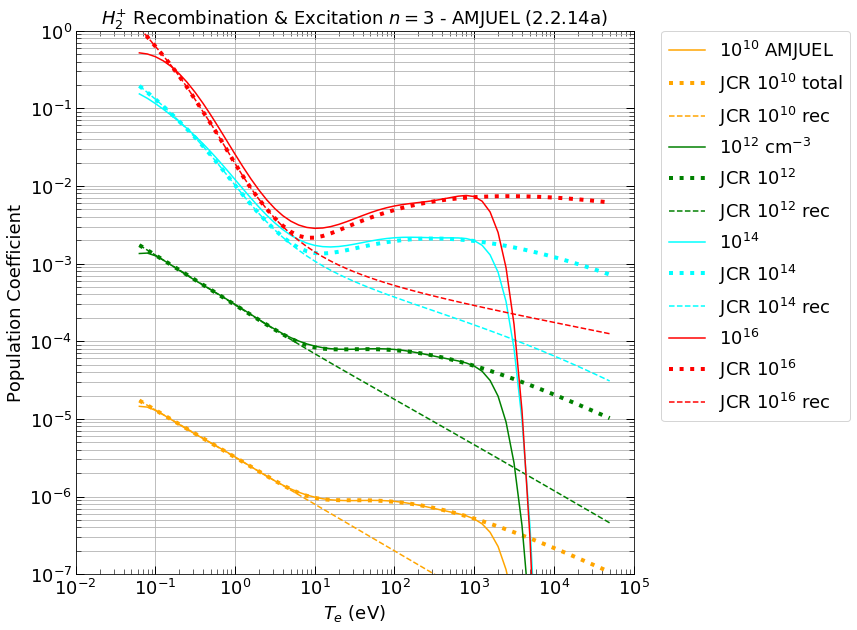

In [14]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,data_2214a[0,:],label='$10^{10}$ AMJUEL',color='orange')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[0,:,1]+H2p_exc_popn_coef[0,:,1]),
         label='JCR $10^{10}$ total',color='orange',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[0,:,1]),
         label='JCR $10^{10}$ rec',color='orange',ls='--')
plt.plot(ehr19Te,data_2214a[4,:],label='$10^{12}$ cm$^{-3}$',color='green')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[4,:,1]+H2p_exc_popn_coef[4,:,1]),
         label='JCR $10^{12}$',color='green',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[4,:,1]),
         label='JCR $10^{12}$ rec',color='green',ls='--')
plt.plot(ehr19Te,data_2214a[8,:],label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[8,:,1]+H2p_exc_popn_coef[8,:,1]),
         label='JCR $10^{14}$',color='cyan',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[8,:,1]),
         label='JCR $10^{14}$ rec',color='cyan',ls='--')
plt.plot(ehr19Te,data_2214a[12,:],label='$10^{16}$',color='red')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[12,:,1]+H2p_exc_popn_coef[12,:,1]),
         label='JCR $10^{16}$',color='red',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[12,:,1]),
         label='JCR $10^{16}$ rec',color='red',ls='--')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Population Coefficient',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
plt.gca().set_xlim((0.01,1.e5))
plt.gca().set_ylim((1.e-7,1.0))
plt.gca().grid(axis='both',which='major')
plt.gca().grid(axis='y',which='minor')
plt.title('$H_{2}^{+}$ Recombination & Excitation $n=3$ - AMJUEL (2.2.14a)',fontsize=18)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',borderaxespad=0,fontsize=18)

In [15]:
H123 = 'H.12'
reacstr = '2.2.14b'
fit_coef = amjuel.get_AMJUEL_fit(amj_file,H123,reacstr)
data_2214b = np.zeros((num_ne,num_Te))
for jt in range(num_Te):
    for jn in range(num_ne):
        data_2214b[jn,jt] = amjuel.ne_Te_exp_fit(fit_coef,ehr19ne[jn],ehr19Te[jt])

/Users/dstotler/degas2/data/H2_CR_model/amjuel.py:64: RuntimeWarning: overflow encountered in exp
  fit = np.exp(fit)


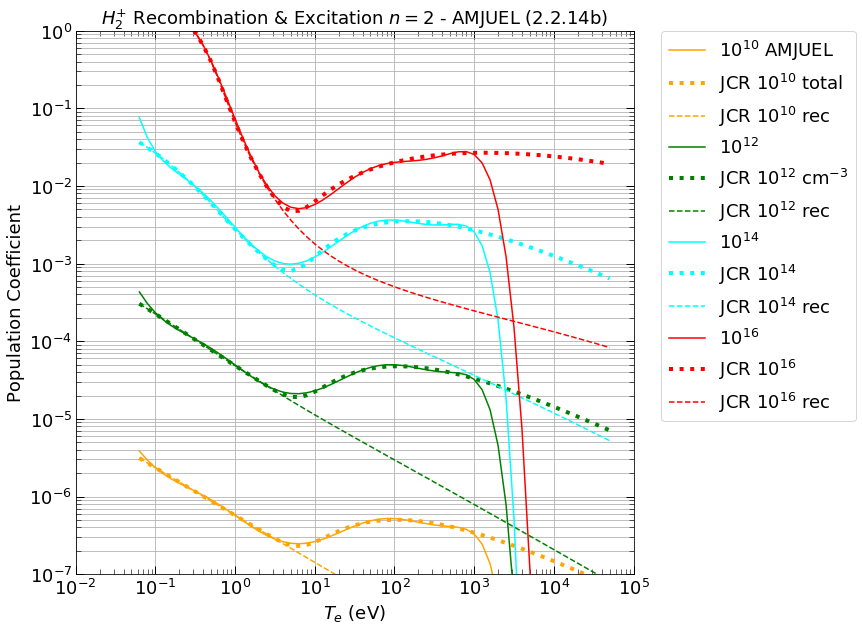

In [16]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,data_2214b[0,:],label='$10^{10}$ AMJUEL',color='orange')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[0,:,0]+H2p_exc_popn_coef[0,:,0]),
         label='JCR $10^{10}$ total',color='orange',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[0,:,0]),
         label='JCR $10^{10}$ rec',color='orange',ls='--')
plt.plot(ehr19Te,data_2214b[4,:],label='$10^{12}$',color='green')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[4,:,0]+H2p_exc_popn_coef[4,:,0]),
         label='JCR $10^{12}$ cm$^{-3}$',color='green',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[4,:,0]),
         label='JCR $10^{12}$ rec',color='green',ls='--')
plt.plot(ehr19Te,data_2214b[8,:],label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[8,:,0]+H2p_exc_popn_coef[8,:,0]),
         label='JCR $10^{14}$',color='cyan',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[8,:,0]),
         label='JCR $10^{14}$ rec',color='cyan',ls='--')
plt.plot(ehr19Te,data_2214b[12,:],label='$10^{16}$',color='red')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[12,:,0]+H2p_exc_popn_coef[12,:,0]),
         label='JCR $10^{16}$',color='red',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[12,:,0]),
         label='JCR $10^{16}$ rec',color='red',ls='--')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Population Coefficient',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
plt.gca().set_xlim((0.01,1.e5))
plt.gca().set_ylim((1.e-7,1.0))
plt.gca().grid(axis='both',which='major')
plt.gca().grid(axis='y',which='minor')
plt.title('$H_{2}^{+}$ Recombination & Excitation $n=2$ - AMJUEL (2.2.14b)',fontsize=18)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',borderaxespad=0,fontsize=18)

In [17]:
H123 = 'H.12'
reacstr = '2.2.14c'
fit_coef = amjuel.get_AMJUEL_fit(amj_file,H123,reacstr)
data_2214c = np.zeros((num_ne,num_Te))
for jt in range(num_Te):
    for jn in range(num_ne):
        data_2214c[jn,jt] = amjuel.ne_Te_exp_fit(fit_coef,ehr19ne[jn],ehr19Te[jt])

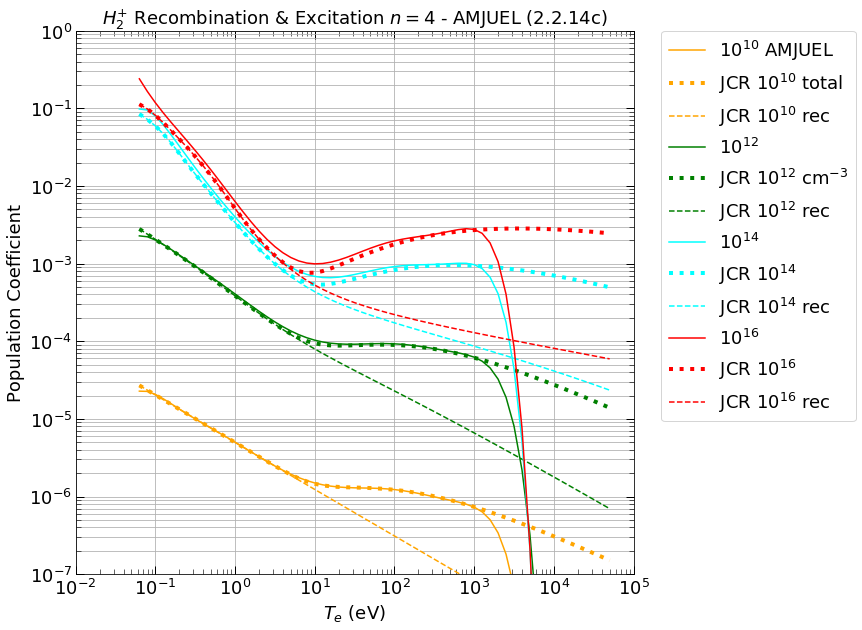

In [18]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,data_2214c[0,:],label='$10^{10}$ AMJUEL',color='orange')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[0,:,2]+H2p_exc_popn_coef[0,:,2]),
         label='JCR $10^{10}$ total',color='orange',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[0,:,2]),
         label='JCR $10^{10}$ rec',color='orange',ls='--')
plt.plot(ehr19Te,data_2214c[4,:],label='$10^{12}$',color='green')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[4,:,2]+H2p_exc_popn_coef[4,:,2]),
         label='JCR $10^{12}$ cm$^{-3}$',color='green',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[4,:,2]),
         label='JCR $10^{12}$ rec',color='green',ls='--')
plt.plot(ehr19Te,data_2214c[8,:],label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[8,:,2]+H2p_exc_popn_coef[8,:,2]),
         label='JCR $10^{14}$',color='cyan',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[8,:,2]),
         label='JCR $10^{14}$ rec',color='cyan',ls='--')
plt.plot(ehr19Te,data_2214c[12,:],label='$10^{16}$',color='red')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[12,:,2]+H2p_exc_popn_coef[12,:,2]),
         label='JCR $10^{16}$',color='red',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[12,:,2]),
         label='JCR $10^{16}$ rec',color='red',ls='--')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Population Coefficient',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
plt.gca().set_xlim((0.01,1.e5))
plt.gca().set_ylim((1.e-7,1.0))
plt.gca().grid(axis='both',which='major')
plt.gca().grid(axis='y',which='minor')
plt.title('$H_{2}^{+}$ Recombination & Excitation $n=4$ - AMJUEL (2.2.14c)',fontsize=18)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',borderaxespad=0,fontsize=18)

In [19]:
H123 = 'H.12'
reacstr = '2.2.14d'
fit_coef = amjuel.get_AMJUEL_fit(amj_file,H123,reacstr)
data_2214d = np.zeros((num_ne,num_Te))
for jt in range(num_Te):
    for jn in range(num_ne):
        data_2214d[jn,jt] = amjuel.ne_Te_exp_fit(fit_coef,ehr19ne[jn],ehr19Te[jt])

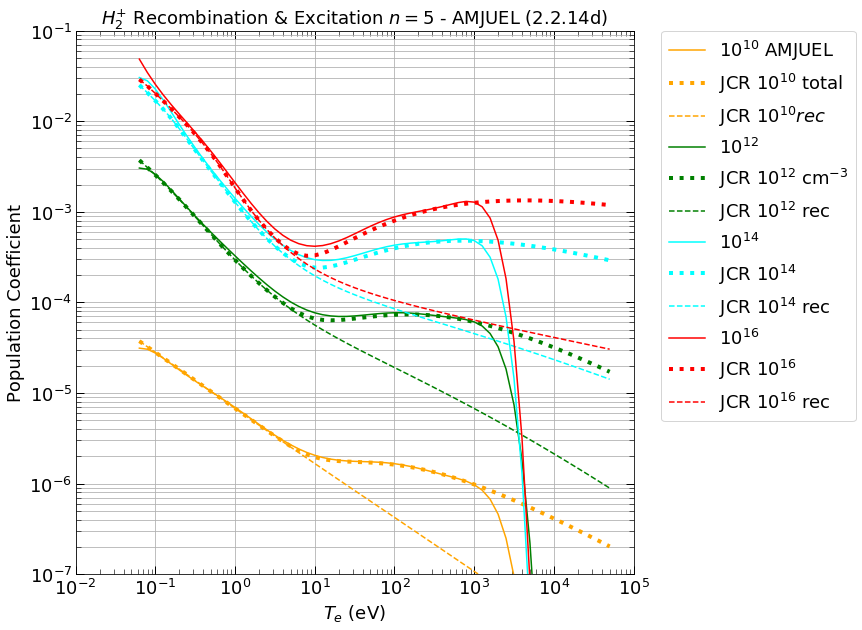

In [20]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,data_2214d[0,:],label='$10^{10}$ AMJUEL',color='orange')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[0,:,3]+H2p_exc_popn_coef[0,:,3]),
         label='JCR $10^{10}$ total',color='orange',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[0,:,3]),
         label='JCR $10^{10} rec$',color='orange',ls='--')
plt.plot(ehr19Te,data_2214d[4,:],label='$10^{12}$',color='green')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[4,:,3]+H2p_exc_popn_coef[4,:,3]),
         label='JCR $10^{12}$ cm$^{-3}$',color='green',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[4,:,3]),
         label='JCR $10^{12}$ rec',color='green',ls='--')
plt.plot(ehr19Te,data_2214d[8,:],label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[8,:,3]+H2p_exc_popn_coef[8,:,3]),
         label='JCR $10^{14}$',color='cyan',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[8,:,3]),
         label='JCR $10^{14}$ rec',color='cyan',ls='--')
plt.plot(ehr19Te,data_2214d[12,:],label='$10^{16}$',color='red')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[12,:,3]+H2p_exc_popn_coef[12,:,3]),
         label='JCR $10^{16}$',color='red',lw=4,ls=':')
plt.plot(ehr19Te,
         (H2p_rec_popn_coef[12,:,3]),
         label='JCR $10^{16}$ rec',color='red',ls='--')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Population Coefficient',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
plt.gca().set_xlim((0.01,1.e5))
plt.gca().set_ylim((1.e-7,0.1))
plt.gca().grid(axis='both',which='major')
plt.gca().grid(axis='y',which='minor')
plt.title('$H_{2}^{+}$ Recombination & Excitation $n=5$ - AMJUEL (2.2.14d)',fontsize=18)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',borderaxespad=0,fontsize=18)

The only lines we currently maintain in the H CR model are Balmer $\alpha$ ($n = 3 \rightarrow 2$), $\beta$ ($n = 4 \rightarrow 2$), and $\gamma$ ($n= 5 \rightarrow 2$) and Lyman $\alpha$ ($n = 2 \rightarrow 1$).  In the interest of simplicity and consistency, have just copied the transition energies and rates from reactionwrite.web, but using eV here instead of ergs.

In [21]:
Eionize = 13.595
E_32 = Eionize * (1./2.**2 - 1./3.**2)
A_32 = 4.41e7
E_21 = Eionize * (1. - 1./2.**2)
A_21 = 4.699e8
E_42 = Eionize * (1./2.**2 - 1./4.**2)
A_42 = 8.419e6
E_52 = Eionize * (1./2.**2 - 1./5.**2)
A_52 = 2.530e6

By convention, the quantity in the files is the emission rate per neutral (here, H$_{2}^{+}$) and per electron.  So, we divide out the electron density.

In [22]:
emission_rate_balmer_alpha = np.zeros((num_ne,num_Te))
emission_rate_balmer_beta = np.zeros((num_ne,num_Te))
emission_rate_balmer_gamma = np.zeros((num_ne,num_Te))
emission_rate_lyman_alpha = np.zeros((num_ne,num_Te))
for jn in range(num_ne):
    emission_rate_balmer_alpha[jn,:] = E_32*A_32*H2p_rec_popn_coef[jn,:,3-2]/ehr19ne[jn]
    emission_rate_balmer_beta[jn,:] = E_42*A_42*H2p_rec_popn_coef[jn,:,4-2]/ehr19ne[jn]
    emission_rate_balmer_gamma[jn,:] = E_52*A_52*H2p_rec_popn_coef[jn,:,5-2]/ehr19ne[jn]
    emission_rate_lyman_alpha[jn,:] = E_21*A_21*H2p_rec_popn_coef[jn,:,2-2]/ehr19ne[jn]

In the previous DEGAS 2 model for molecular ion recombination, only an $n=3$ excited product was included.  The JLEP prescription for (2.2.14) included the fraction of the products in each excited state, with 0.45 in $n=3$.  

Extract the previous data from the netCDF file and make a comparison plot:

In [23]:
h2pdisrec_nc.xs.print_var(3)
old_Dalpha_rate = h2pdisrec_nc.xs.get_var4plot(3)

Dependent variable:  emission_rate  Units:  eV*cm^3/s 
 Multiplier:  1.60218e-25  Spacing:  log 

  Indep. var.     Units    Multiplier  Spacing     Min.        Max.    
temperature     eV         1.60218e-19 log      1.00000e+00 5.01187e+04


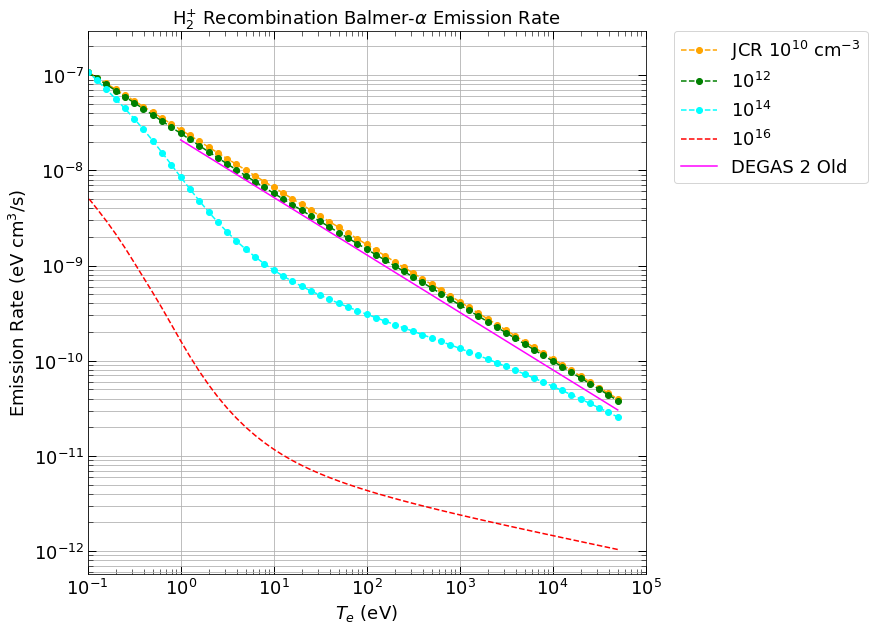

In [24]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,
         emission_rate_balmer_alpha[0,:],'-o',
         label='JCR $10^{10}$ cm$^{-3}$',color='orange',ls='--')
plt.plot(ehr19Te,
         emission_rate_balmer_alpha[4,:],'-o',
         label='$10^{12}$',color='green',ls='--')
plt.plot(ehr19Te,
         emission_rate_balmer_alpha[8,:],'-o',
         label='$10^{14}$',color='cyan',ls='--')
plt.plot(ehr19Te,
         emission_rate_balmer_alpha[12,:],
         label='$10^{16}$',color='red',ls='--')
plt.plot(old_Dalpha_rate[0],old_Dalpha_rate[1],label='DEGAS 2 Old',color='magenta')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Emission Rate (eV cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
plt.gca().set_xlim((0.1,1.e5))
#plt.gca().set_ylim((1.e-16,1.e-8))
plt.gca().grid(axis='both',which='major')
plt.gca().grid(axis='y',which='minor')
plt.title(r'H$_{2}^{+}$ Recombination Balmer-$\alpha$ Emission Rate',fontsize=18)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',borderaxespad=0,fontsize=18)

The coronal limit of the new rate is slightly larger than the old one due to contributions from the decay of higher states to $n = 3$.

Writing the data to the netCDF file consists of two steps.  The first involves defining the independent and dependent variables and then setting up the data table that holds all of the actual rate data.

The variables being written to this file are: 

0. Reaction rate(temperature,density)
1. Dissociation energy (scalar)
2. Background energy loss rate (temperature,density)
3. Emission rate (temperature, density) - default rate is for Balmer-$\alpha$.
4. Emission rate Lyman-$\alpha$ (temperature, density)
5. Emission rate Balmer-$\beta$ (temperature, density)
6. Emission rate Balmer-$\gamma$ (temperature, density)
7. Wavelength H$_{\alpha}$ (emitter mass)
8. Wavelength D$_{\alpha}$ (emitter mass)
10. Wavelength T$_{\alpha}$ (emitter mass)
11. Wavelength Lyman-$\alpha$
12. Wavelength Balmer-$\beta$
13. Wavelength Balmer-$\gamma$

As above, there are num_ne density values and num_Te temperature values.   Note that we change from using (density,temperature)  in these notebooks to (temperature,density) in the netCDF files.  The latter is to be consistent with the convention in the H CR files, such as hionize5.nc. The swap is effected by sending the transpose of the data arrays in the set_data method calls below. We use 4 values of the emitter mass to connect the emitting species with its wavelength. 

This initialization call sets the name of the reaction and the netCDF file, and specifies the number of dependent variables.

In [25]:
h2pdisrec = xs.xs_data('h2pdisrec_jcr',13)

Now, loop through the variables, providing the name, evaluation name (not really used), dimensions, units, multiplier, independent variable minimum and maximum, and the spacing method used for interpolation.

In [26]:
h2pdisrec.set_var(0,['reaction_rate','temperature','density'],'table',
              [num_Te,num_ne],['cm^3/s','eV','cm^-3'],
              [1.e-6,xs.electron_charge,1.e6],
              [ehr19Te[0],ehr19ne[0]],
              [ehr19Te[-1],ehr19ne[-1]],
              ['log']*3)

In [27]:
h2pdisrec.set_var(1,['dissociation_energy'],'table',
              [],['eV'],
              [xs.electron_charge],
              [],
              [],
              ['linear'])

In [28]:
for j in range(2,7):
    rate_names = ['background_energy_loss_rate','emission_rate',
           'emission_rate_Lyman_alpha','emission_rate_Balmer_beta',
           'emission_rate_Balmer_gamma']
    h2pdisrec.set_var(j,[rate_names[j-2],'temperature','density'],'table',
                  [num_Te,num_ne],['eV*cm^3/s','eV','cm^-3'],
                  [1.e-6*xs.electron_charge,xs.electron_charge,1.e6],
                  [ehr19Te[0],ehr19ne[0]],
                  [ehr19Te[-1],ehr19ne[-1]],
                  ['log']*3)

In [29]:
for j in range(7,10):
    B_wave_names = ['wavelength_H_alpha','wavelength_D_alpha','wavelength_T_alpha']
    # 
    # Copied these from existing files
    #
    wave_mins = [1.5e-27,3.2e-27,4.85e-27]
    wave_maxs = [1.8e-27,3.5e-27,5.15e-27]
    h2pdisrec.set_var(j,[B_wave_names[j-7],'emitter_mass'],'table',
                  [4],['Angstroms','kilograms'],
                  [1.e-10,1.],
                  [wave_mins[j-7]],
                  [wave_maxs[j-7]],
                  ['linear']*2)

In [30]:
for j in range(10,13):
    wave_names = ['wavelength_Lyman_alpha','wavelength_Balmer_beta',
                  'wavelength_Balmer_gamma'] 
    #
    # Note that the use of table_external here is only
    # for consistency with reactionwrite.web; the particular
    # value has no meaning since we are not using ratecalc here.
    #
    h2pdisrec.set_var(j,[wave_names[j-10]],'table_external',
                  [],['Angstroms'],
                  [1.e-10],
                  [],
                  [],
                  ['linear'])

Fill in the data table.

The wavelength values are entered manually by copying them from reactionwrite.web.

In [31]:
h2pdisrec.set_data(0,R_H2p.T)
h2pdisrec.set_data(1,E_diss)
h2pdisrec.set_data(2,E_loss_rate.T)
h2pdisrec.set_data(3,emission_rate_balmer_alpha.T)
h2pdisrec.set_data(4,emission_rate_lyman_alpha.T)
h2pdisrec.set_data(5,emission_rate_balmer_beta.T)
h2pdisrec.set_data(6,emission_rate_balmer_gamma.T)
h2pdisrec.set_data(7,np.array([0.,6.56280e3,6.56280e3,0.]))  # H Balmer-alpha
h2pdisrec.set_data(8,np.array([0.,6.56104e3,6.56104e3,0.]))  # D
h2pdisrec.set_data(9,np.array([0.,6.56045e3,6.56045e3,0.]))  # T
h2pdisrec.set_data(10,1.215668e3)  # Lyman-alpha
h2pdisrec.set_data(11,4.861e3)     # Balmer-beta
h2pdisrec.set_data(12,4.341e3)     # Balmer-gamma

Now open the netCDF file, write in the data using the h2pdisrec xs_data data structures, and close the file.

In [32]:
work_dir = './'
h2pdisrec_nc = xs.xs_netCDF.write_ncfile(h2pdisrec,work_dir,
                        'Reference atomic physics data for a reaction in degas 2',
                        'V. 1.0, effective H2+ recombination with CR effects')
h2pdisrec_nc.close()